# Qwen3-VL experiments

Re-runnable report notebook for the Qwen3-VL experiments used in the thesis. It contains the main saved results, plots, and configuration notes. Full training and evaluation scripts are available in `src/fine_tuning/qwen3vl_lora/` and `src/zero_shot/`.

## Legend

- Base checkpoint: `Qwen/Qwen3-VL-2B-Instruct`.
- Fine-tuning: LoRA/PEFT with frozen base weights.
- Tested variants: standard LoRA, dysgraphia oversampling, and mixed-domain LoRA.
- Metrics: corpus CER, corpus WER, corpus CLA, corpus CRW, mean inference time, and peak VRAM where measurable.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'


Loaded repository paths: results/tables and results/figures


## How to reuse this notebook

This notebook is both a saved experiment report and a runnable analysis notebook. A forked repository can be used in two ways:

- inspect the already saved outputs without running anything,
- rerun the cells after replacing files in `results/tables/` or `results/figures/`, or after producing new files with scripts from `src/`.

For new experiments, keep the original thesis outputs unchanged and save custom outputs under `results/custom_tables/` and `results/custom_figures/`.

In [2]:
RUN_TAG = 'custom'
CUSTOM_TABLES = ROOT / 'results' / 'custom_tables'
CUSTOM_FIGURES = ROOT / 'results' / 'custom_figures'
CUSTOM_TABLES.mkdir(parents=True, exist_ok=True)
CUSTOM_FIGURES.mkdir(parents=True, exist_ok=True)

def save_table(df, filename):
    """Save a custom result table under results/custom_tables/."""
    path = CUSTOM_TABLES / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path

def save_figure(fig, filename, dpi=200):
    """Save a custom matplotlib figure under results/custom_figures/."""
    path = CUSTOM_FIGURES / filename
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'Saved figure: {path}')
    return path

print(f'Custom outputs will be saved to: {CUSTOM_TABLES} and {CUSTOM_FIGURES}')

Custom outputs will be saved to: results/custom_tables and results/custom_figures


## Zero-shot evaluation


In [2]:
pd.read_csv(TABLES / 'zero_shot_polish_test.csv').query("family == 'Qwen3VL'")


family,model,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Qwen3VL,Qwen3-VL-2B-Instruct,241,0.2267,0.5073,0.8027,0.5409


In [3]:
pd.read_csv(TABLES / 'iam_200_summary_selected.csv').query("model == 'Qwen3VL'")


model,variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Qwen3VL,base,200,0.0557,0.3142,0.9793,0.6883
Qwen3VL,LoRA standard,200,0.0724,0.3469,0.9655,0.6561
Qwen3VL,LoRA mixed-domain,200,0.0688,0.3363,0.9682,0.6697


In [4]:
pd.read_csv(TABLES / 'malaysian_summary_selected.csv').query("model == 'Qwen3VL'")


model,variant,dataset,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Qwen3VL,zero-shot,Malaysian raw,424,0.0739,0.2342,0.9451,0.7776
Qwen3VL,zero-shot,Malaysian inverted,424,0.0734,0.2315,0.9462,0.7835
Qwen3VL,Polish LoRA standard,Malaysian raw,424,0.0806,0.2287,0.9399,0.7851
Qwen3VL,Polish LoRA standard,Malaysian inverted,424,0.0841,0.2303,0.9349,0.7796
Qwen3VL,mixed-domain LoRA held-out,Malaysian inverted,66,0.0108,0.0258,0.9937,0.9767


## LoRA fine-tuning


In [5]:
pd.read_csv(TABLES / 'fine_tuning_polish_test.csv').query("model == 'Qwen3VL'")


model,variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Qwen3VL,LoRA standard,241,0.0120,0.0435,0.9908,0.9582
Qwen3VL,LoRA oversampling,241,0.0080,0.0371,0.9939,0.9646
Qwen3VL,LoRA mixed-domain,241,0.0136,0.0459,0.9894,0.9576


LoRA strongly reduced the error on the Polish test set. Dysgraphia oversampling was the best in-domain Qwen3-VL variant, while the mixed-domain variant was mainly useful for the held-out Malaysian test split.


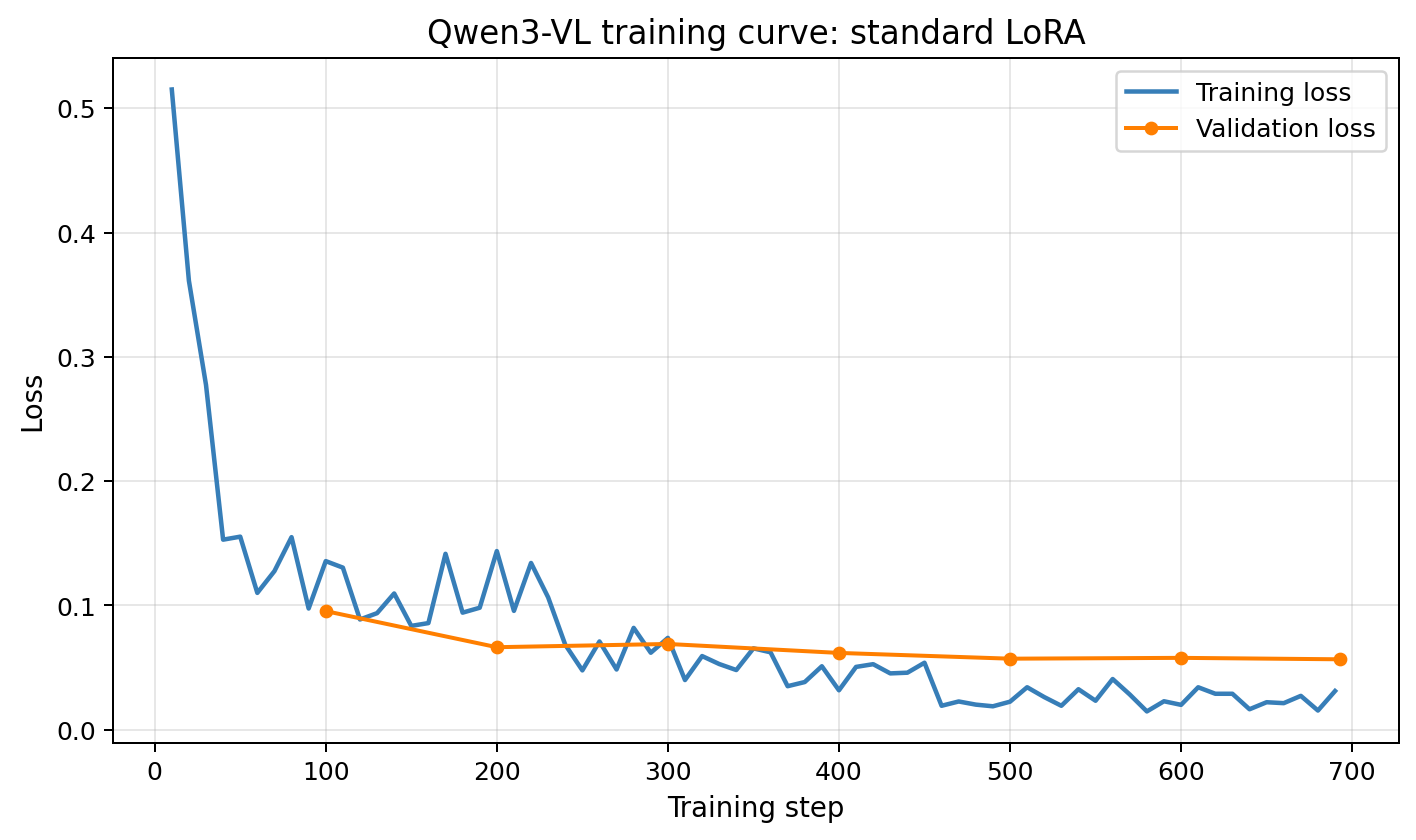

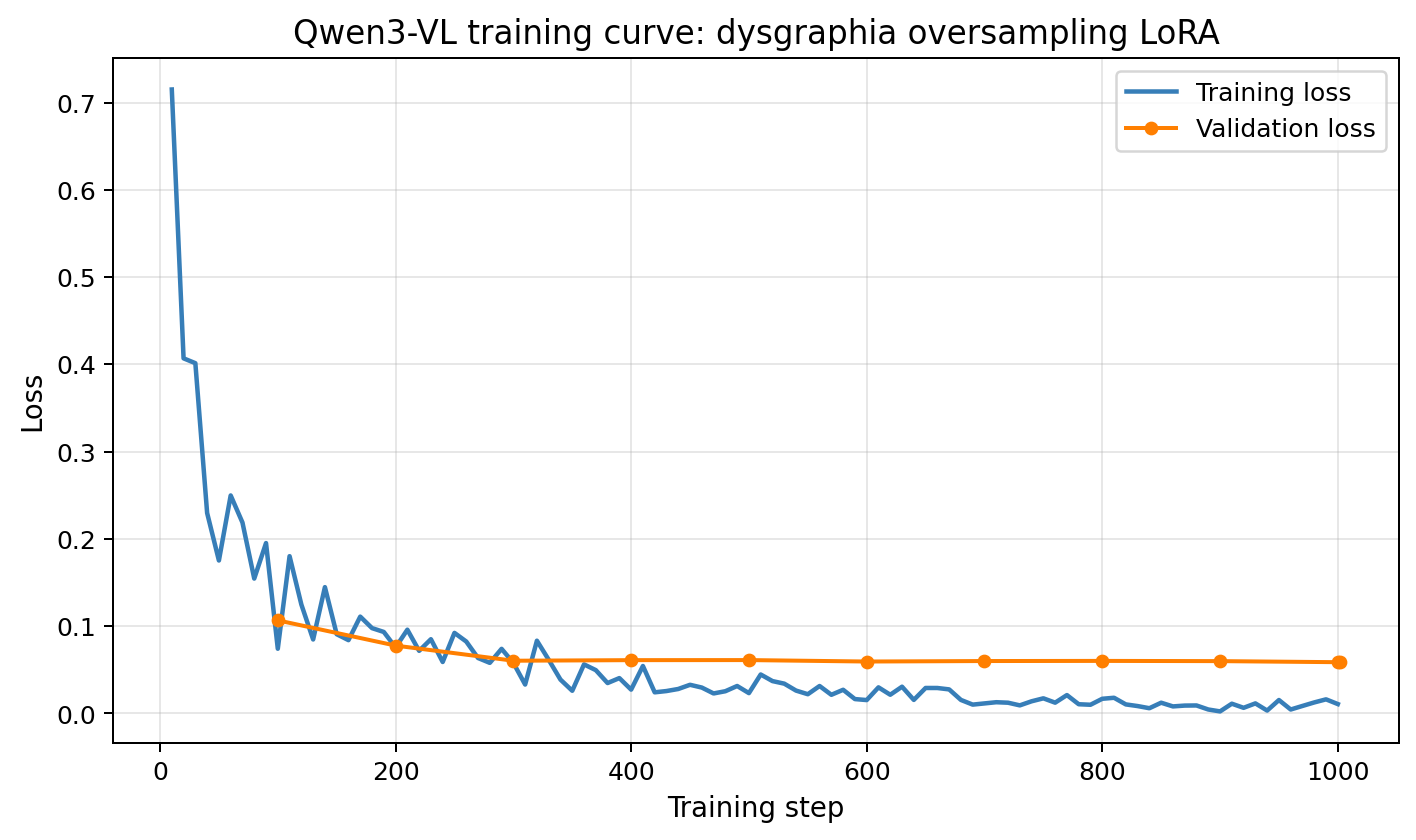

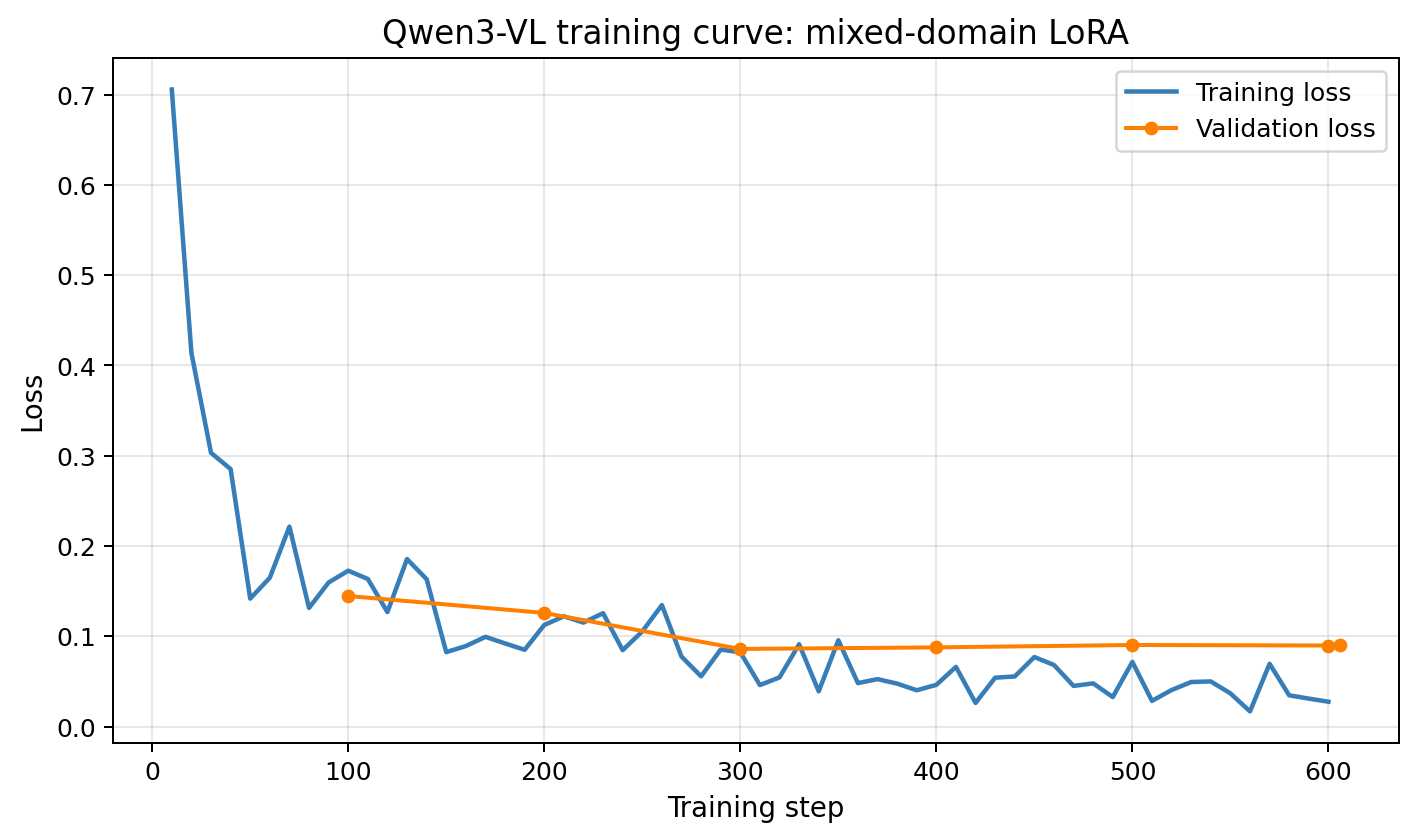

In [6]:
display(Image(filename=str(FIGURES / 'qwen_training_standard.png')))
display(Image(filename=str(FIGURES / 'qwen_training_dysgraphia_oversampled.png')))
display(Image(filename=str(FIGURES / 'qwen_training_mixed_domain.png')))


## Resource usage


In [7]:
pd.read_csv(TABLES / 'resource_summary_selected.csv').query("model == 'Qwen3VL'")


model,variant,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max,rss_after_mb_max
Qwen3VL,LoRA oversampling,1.4950,4258.5000,4348.0000,NaN


## Character-level error analysis


In [8]:
pd.read_csv(TABLES / 'top_character_substitutions_best_models.csv').query("model == 'Qwen3-VL'").head(12)


model,operation,reference_char,predicted_char,count
Qwen3-VL,substitution,e,ę,7.0000
Qwen3-VL,substitution,l,ł,4.0000
Qwen3-VL,substitution,e,c,3.0000
Qwen3-VL,substitution,o,a,3.0000
Qwen3-VL,substitution,K,k,2.0000
Qwen3-VL,substitution,ę,e,2.0000
Qwen3-VL,substitution,Ś,S,2.0000
Qwen3-VL,substitution,P,p,2.0000
Qwen3-VL,substitution,z,ż,2.0000
Qwen3-VL,substitution,S,Ś,1.0000


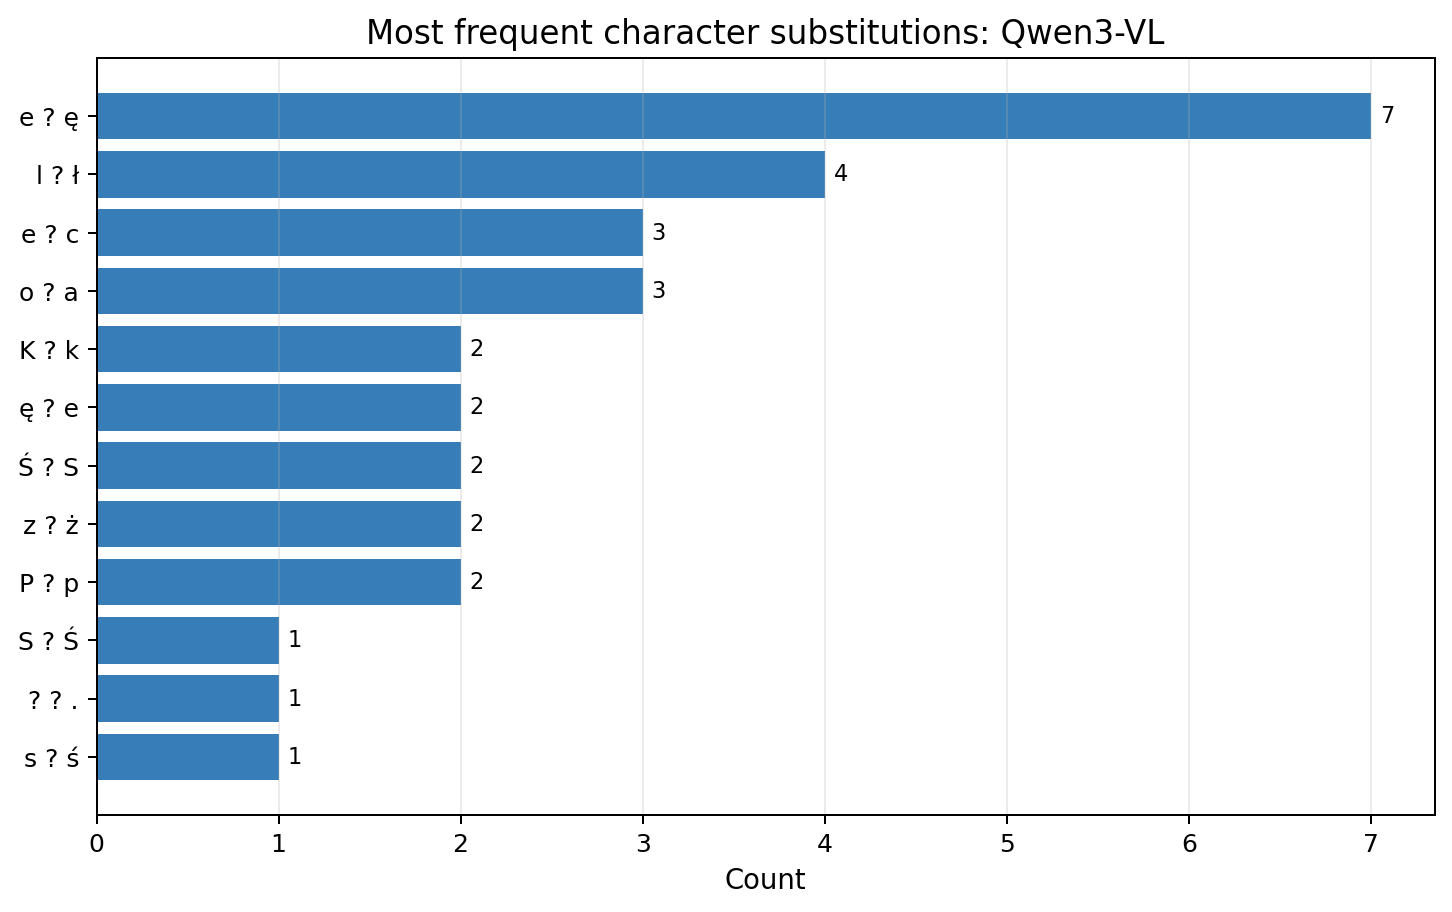

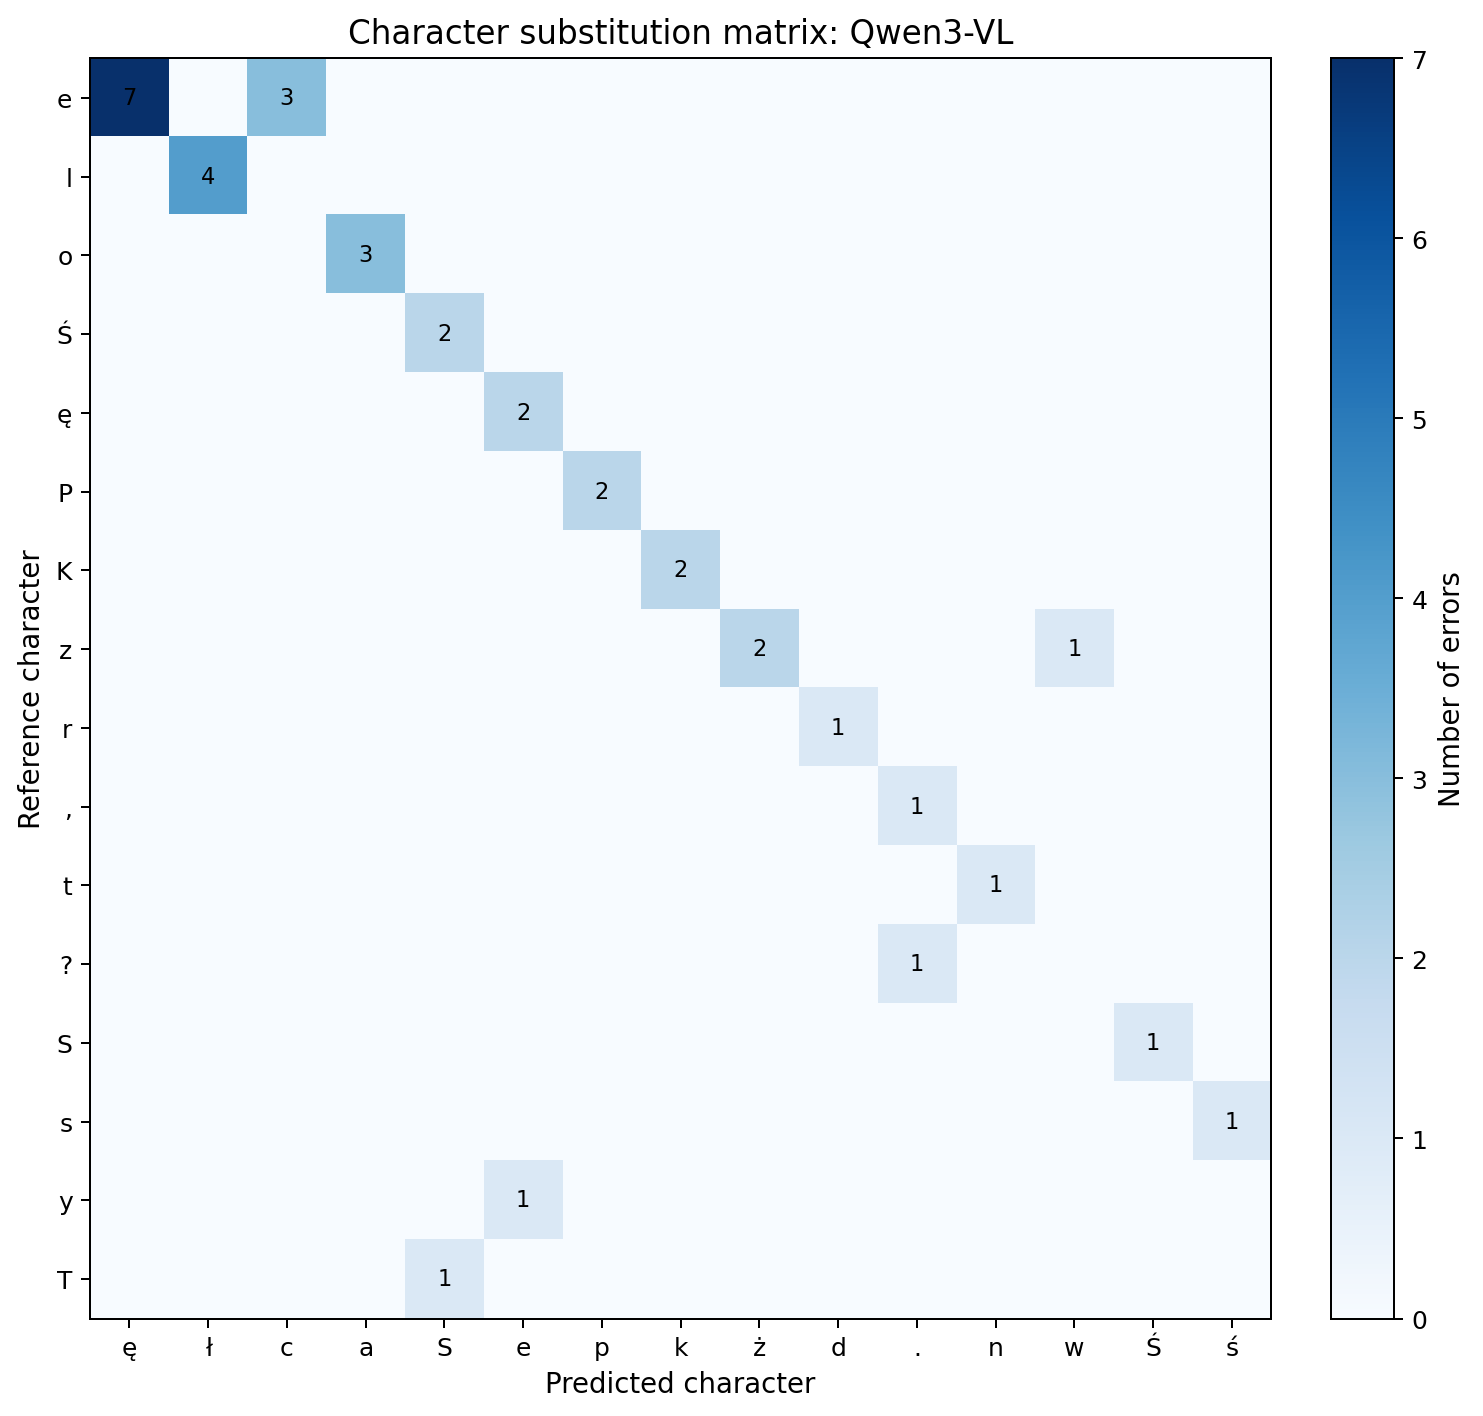

In [9]:
display(Image(filename=str(FIGURES / 'top_character_substitutions_qwen3_vl.png')))
display(Image(filename=str(FIGURES / 'character_substitution_heatmap_qwen3_vl.png')))
